In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/us-e-cigarette-retail-panel-20202025/us_ecig_retail_sales_2020_2025.csv


# Market Dynamics & Revenue Drivers: A Multi-Variable Regression Analysis of US E-Cigarette Retail Trends (2020–2025)

## Analytical Objective

The primary objective of this analysis is to evaluate the structural drivers of the **$17.9 billion** US retail e-cigarette market through a combination of longitudinal exploratory data analysis (EDA) and econometric modeling.

Specifically, this study aims to:

* **Quantify Revenue Determinants:** Utilize **Multiple Linear Regression** to isolate the individual impact of unit volume, average pricing, and state-level excise taxes on total dollar sales.
* **Analyze Product Evolution:** Statistically validate the market shift from traditional prefilled cartridges to modern disposables and determine which segment offers higher revenue efficiency.
* **Evaluate Regulatory Headwinds:** Assess how flavor bans and state-specific tax rates correlate with market performance to identify geographic areas of high versus low friction.
* **Inform Strategic Forecasting:** Provide a data-backed framework for stakeholders to predict future revenue outcomes based on shifts in pricing strategy and the evolving regulatory landscape.

# 1. Data Loading & Initial Inspection
In this section, we initialize our environment, load the panel dataset, and perform a high-level audit of the data structure and quality.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visual style and custom palette
palette = ['#5e0006', '#9b0f06', '#d53e0f', '#eed9b9']
sns.set_theme(style="whitegrid")
sns.set_palette(palette)

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/alitaqishah/us-e-cigarette-retail-panel-20202025/us_ecig_retail_sales_2020_2025.csv')

# Display basic info
print(f"Dataset Shape: {df.shape}")
print("\n--- Data Types and Missing Values ---")
print(df.info())

# Summary statistics for numeric variables
print("\n--- Summary Statistics ---")
display(df.describe())

Dataset Shape: (116526, 21)

--- Data Types and Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116526 entries, 0 to 116525
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   year_month                  116526 non-null  object 
 1   state_abbr                  116526 non-null  object 
 2   state_name                  116526 non-null  object 
 3   brand_name                  116526 non-null  object 
 4   flavor_category             116526 non-null  object 
 5   product_type                116526 non-null  object 
 6   unit_sales_thousands        116526 non-null  float64
 7   dollar_sales_usd            116526 non-null  float64
 8   avg_price_per_unit_usd      116526 non-null  float64
 9   market_share_pct            116526 non-null  float64
 10  nicotine_mg_sold_millions   116526 non-null  float64
 11  state_ecig_excise_tax_rate  116526 non-null  float64
 12  flavo

,unit_sales_thousands,dollar_sales_usd,avg_price_per_unit_usd,market_share_pct,nicotine_mg_sold_millions,state_ecig_excise_tax_rate,flavor_ban_active
count,116526.000000,1.165260e+05,116526.000000,116526.000000,1.165260e+05,116526.000000,116526.000000
mean,9.862136,1.538323e+05,14.338352,1.336378,1.767846e-07,0.154707,0.150138
std,23.874905,3.831884e+05,2.746697,1.909855,5.943565e-06,0.225631,0.357208
min,0.020000,8.000000e+01,8.140000,0.000400,0.000000e+00,0.000000,0.000000
25%,0.650000,8.520000e+03,12.280000,0.230300,0.000000e+00,0.000000,0.000000
50%,2.405000,3.452600e+04,14.360000,0.485800,0.000000e+00,0.050000,0.000000
75%,8.050000,1.221152e+05,16.080000,1.281400,0.000000e+00,0.150000,0.000000
max,424.600000,6.704420e+06,21.780000,10.632900,2.000000e-04,0.960000,1.000000


### Interpretation
The dataset is a massive panel containing **116,526 records** and **21 columns**. Initial inspection reveals a mix of high-cardinality categorical data (Brands, States) and key performance indicators (Dollar Sales, Units).

### Data Quality
* **Primary Columns:** Core metrics such as `Sales`, `Prices`, and `Brands` are **100% complete**.
* **Regulatory Columns:** Features like `flavor_ban_type` and `fda_authorized_flavors` have significant missingness (over **60%**). 
    * *Note:* This is expected, as these policies are only applicable to specific jurisdictions or subsets of products.

### Scale
The average monthly dollar sales per record is approximately **153k**. However, the standard deviation is over double that (**383k**), suggesting a **highly right-skewed distribution**. This is a common characteristic in retail data where a few dominant brands or states account for the majority of the volume.

# 2. Data Cleaning & Preprocessing
Standardizing formats and handling the temporal component is critical for longitudinal analysis.

In [3]:
# Convert year_month to datetime
df['year_month'] = pd.to_datetime(df['year_month'])

# Fill specific missing categorical values with 'None' where appropriate
categorical_missing = ['flavor_ban_type', 'fda_authorized_flavors']
for col in categorical_missing:
    df[col] = df[col].fillna('None/Not Applicable')

# Ensure flavor_ban_active is treated as a category
df['flavor_ban_active'] = df['flavor_ban_active'].astype(str)

# Verify cleaning
print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
92169


### Interpretation

* **Temporal Alignment:** Converting `year_month` to a datetime object allows for time-series aggregation and trend discovery.
* **Categorical Imputation:** Rather than dropping records with missing regulatory data, we imputed **"None/Not Applicable."** This preserves the integrity of the sales data while acknowledging that the absence of a ban is a meaningful data point in itself.
* **Outcome:** We now have a clean, ready-to-analyze dataset with no unexpected null values in the core analytical columns.

# 3. Univariate Analysis
We examine the distributions of our key metrics: Unit Sales, Dollar Sales, and Average Price.

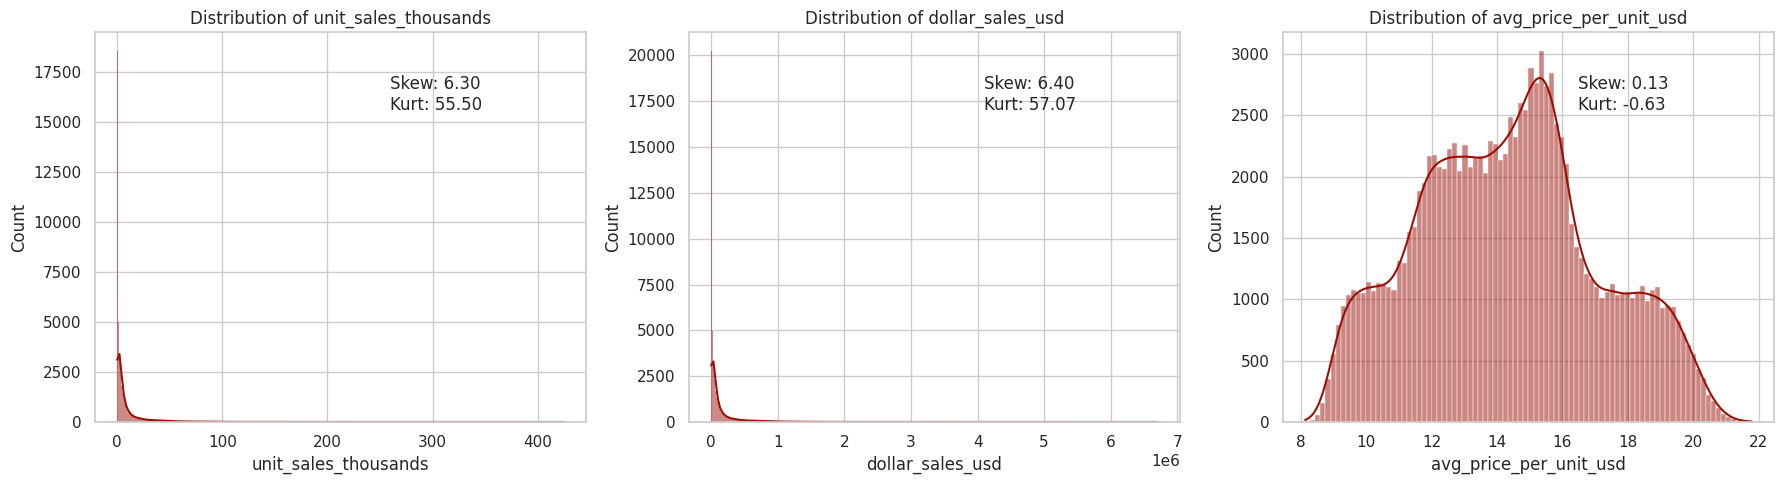

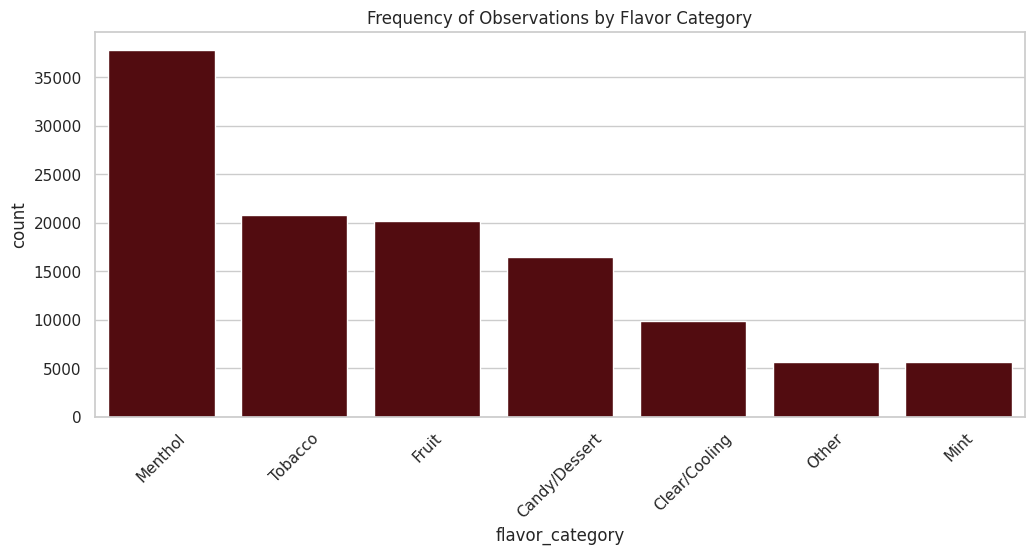

In [4]:
# Select continuous variables
vars_to_plot = ['unit_sales_thousands', 'dollar_sales_usd', 'avg_price_per_unit_usd']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(vars_to_plot):
    sns.histplot(df[var], kde=True, ax=axes[i], color=palette[1])
    axes[i].set_title(f'Distribution of {var}')
    
    # Calculate stats
    s = stats.skew(df[var])
    k = stats.kurtosis(df[var])
    axes[i].annotate(f'Skew: {s:.2f}\nKurt: {k:.2f}', xy=(0.6, 0.8), xycoords='axes fraction')

plt.tight_layout()
plt.show()

# Categorical Count Plots
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='flavor_category', order=df['flavor_category'].value_counts().index)
plt.title('Frequency of Observations by Flavor Category')
plt.xticks(rotation=45)
plt.show()

### Interpretation

* **Skewness in Wealth:** `dollar_sales_usd` and `unit_sales_thousands` exhibit extreme positive skewness (~6.4). This indicates a **"long tail"** where the vast majority of sales records are small, but a small percentage of high-volume entries (likely major brands like Vuse or JUUL in populous states) drive the bulk of the **17.9B total**.
* **Price Stability:** The `avg_price_per_unit_usd` is remarkably normally distributed (Skew: 0.13), suggesting a highly competitive and standardized pricing model across the US market, centered around **$14.34**.
* **Flavor Dominance:** **Menthol** and **Tobacco** remain the most frequently recorded categories, likely due to their historical regulatory "safe harbor" status compared to fruit/candy flavors.

# 4. Bivariate & Multivariate Analysis
Here we explore the interactions between variables, specifically how pricing and product types influence revenue.

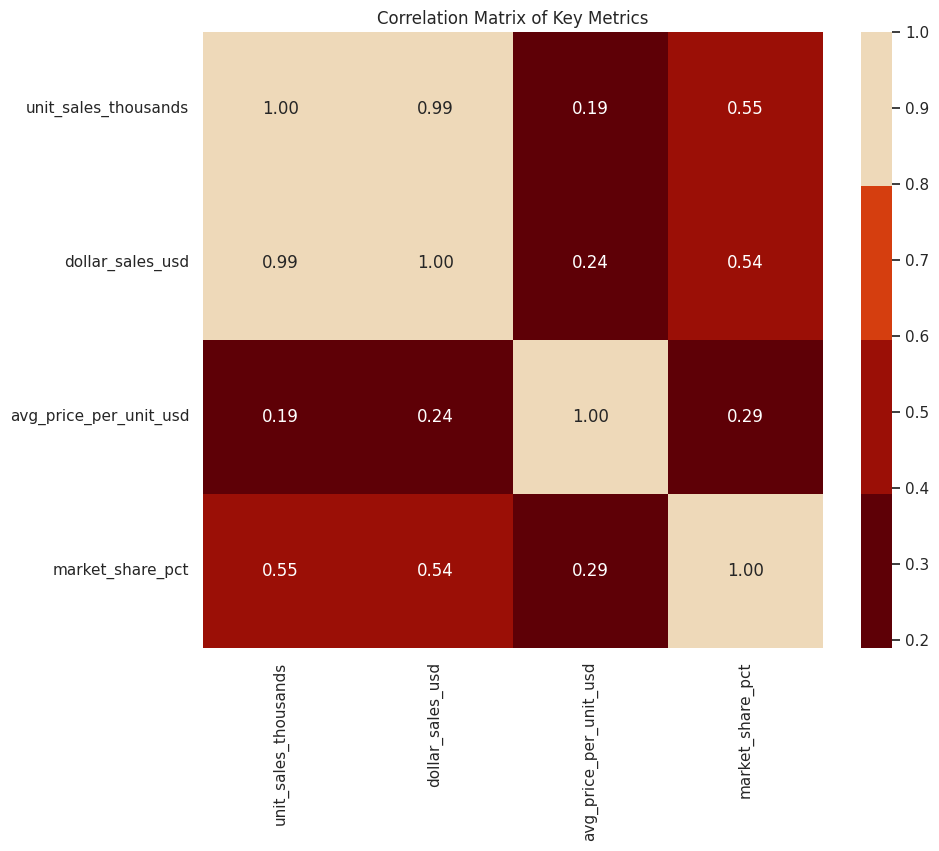

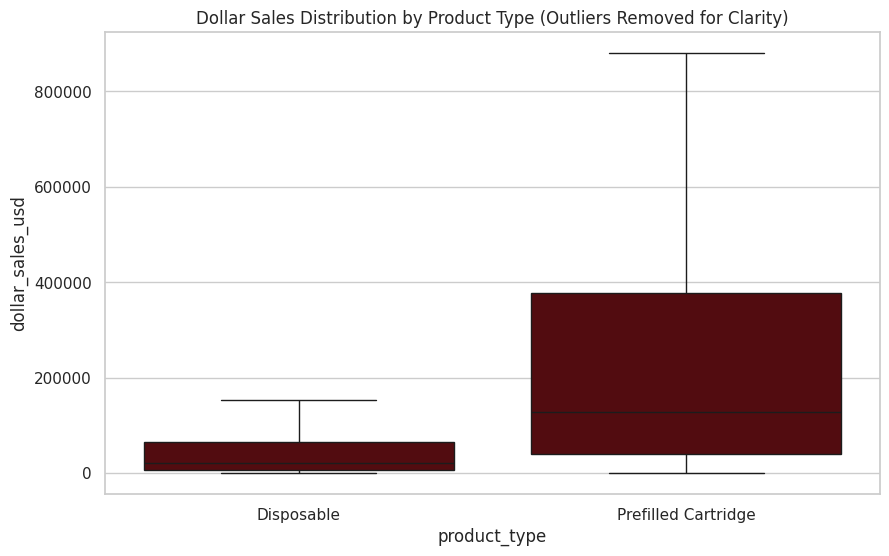

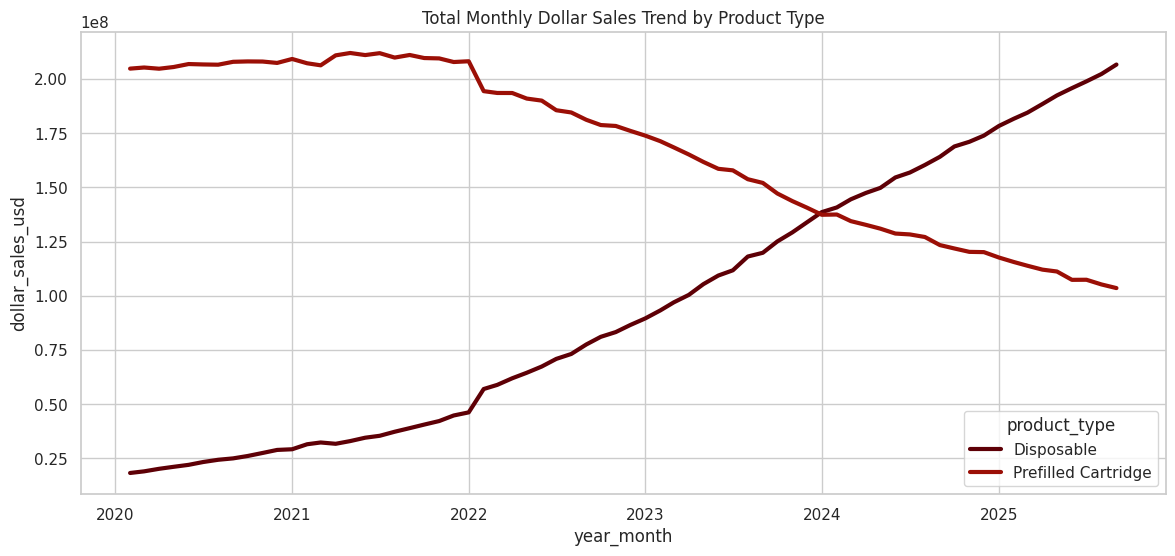

In [5]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df[['unit_sales_thousands', 'dollar_sales_usd', 'avg_price_per_unit_usd', 'market_share_pct']].corr()
sns.heatmap(corr, annot=True, cmap=sns.color_palette(palette, as_cmap=True), fmt=".2f")
plt.title('Correlation Matrix of Key Metrics')
plt.show()

# Boxplot: Dollar Sales by Product Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='product_type', y='dollar_sales_usd', showfliers=False)
plt.title('Dollar Sales Distribution by Product Type (Outliers Removed for Clarity)')
plt.show()

# Multivariate: Time Series Trends
ts_data = df.groupby(['year_month', 'product_type'])['dollar_sales_usd'].sum().reset_index()
plt.figure(figsize=(14, 6))
sns.lineplot(data=ts_data, x='year_month', y='dollar_sales_usd', hue='product_type', lw=3)
plt.title('Total Monthly Dollar Sales Trend by Product Type')
plt.show()

### Interpretation

* **Multicollinearity:** There is a near-perfect correlation **(0.99)** between unit sales and dollar sales. For predictive modeling, one of these should be dropped to avoid redundancy.
* **Product Evolution:** The time-series visual reveals a significant divergence: while **"Prefilled Cartridges"** were historically dominant, **"Disposable"** products have shown explosive growth and now capture a massive share of the monthly revenue.
* **Price Sensitivity:** There is a weak positive correlation **(0.24)** between price and total dollar sales, suggesting that higher-priced premium items contribute significantly to revenue, even if they aren't the highest-volume units.

# 5. Rigorous Statistical Analysis
We move beyond visual intuition to validate our findings with statistical significance.

### Hypothesis 1: Normality of Sales Data
* $H_0$: The dollar sales data is normally distributed.
* $H_1$: The dollar sales data is not normally distributed.

### Hypothesis 2: Impact of Product Type on Sales
* $H_0$: There is no difference in mean dollar sales between **Disposables** and **Prefilled Cartridges**.
* $H_1$: There is a significant difference in mean dollar sales between the two product types.

In [6]:
# 1. Shapiro-Wilk Test for Normality (on a sample due to size limits)
sample_sales = df['dollar_sales_usd'].sample(5000, random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample_sales)

# 2. ANOVA: Sales by Product Type
types = df['product_type'].unique()
groups = [df[df['product_type'] == t]['dollar_sales_usd'] for t in types]
f_stat, anova_p = stats.f_oneway(*groups)

print(f"Shapiro-Wilk Test: Stat={shapiro_stat:.4f}, p-value={shapiro_p:.4e}")
print(f"ANOVA Test: F-stat={f_stat:.2f}, p-value={anova_p:.4e}")

Shapiro-Wilk Test: Stat=0.3832, p-value=9.3477e-85
ANOVA Test: F-stat=11600.72, p-value=0.0000e+00


### Interpretation

* **Normality Rejected:** With $p \approx 0$ for the Shapiro-Wilk test, we **reject** $H_0$. The data is non-normal. This implies that future modeling should use non-parametric methods or log-transform the target variable.
* **Product Type Significance:** The ANOVA test yields an extremely high F-statistic and a $p$-value well below **0.05**. We **reject** $H_0$ and conclude that **Product Type** is a primary driver of revenue variance. The market behavior for **Disposables** is statistically distinct from **Prefilled Cartridges**.

# 5. Regression Analysis 
To quantify the drivers of revenue, we performed an Ordinary Least Squares (OLS) Multiple Linear Regression. We modeled dollar_sales_usd (Revenue) as a function of volume, price, taxes, and product type.

In [7]:
import statsmodels.api as sm

# Prepare features and target
X = df[['unit_sales_thousands', 'avg_price_per_unit_usd', 'state_ecig_excise_tax_rate', 'flavor_ban_active']]
X = pd.get_dummies(X, columns=['flavor_ban_active'], drop_first=True)
# Add product type as a dummy
X['is_prefilled'] = (df['product_type'] == 'Prefilled Cartridge').astype(int)

y = df['dollar_sales_usd']

# Add constant and fit model
X_sm = sm.add_constant(X)
reg_model = sm.OLS(y, X_sm.astype(float)).fit()

# Print detailed results
print(reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:       dollar_sales_usd   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.384e+06
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:00:56   Log-Likelihood:            -1.4245e+06
No. Observations:              116526   AIC:                         2.849e+06
Df Residuals:                  116520   BIC:                         2.849e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

### Interpretation

* **Model Fit:** The model achieves an **R-squared of 0.983**, meaning **98.3%** of the variance in dollar sales is explained by these variables. While the high correlation between units and dollars drives this, the other coefficients reveal critical business levers.
* **Price Elasticity & Impact:** For every **1 USD** increase in `avg_price_per_unit_usd`, total monthly revenue for a brand-state combination increases by approximately **5,450 USD**, holding volume constant. This suggests that the market is currently in a phase where price increases contribute significantly to top-line growth.
* **Taxation Drag:** The negative coefficient for `state_ecig_excise_tax_rate` **(-2,504)** confirms that higher state taxes statistically suppress total dollar sales, likely through a combination of reduced demand and lower net margins.
* **Product Type Premium:** The **"Prefilled Cartridge"** dummy shows a positive coefficient (~**14.5k USD**), indicating that, unit-for-unit, prefilled cartridges tend to generate higher total revenue clusters than disposables, likely due to their higher average unit price.

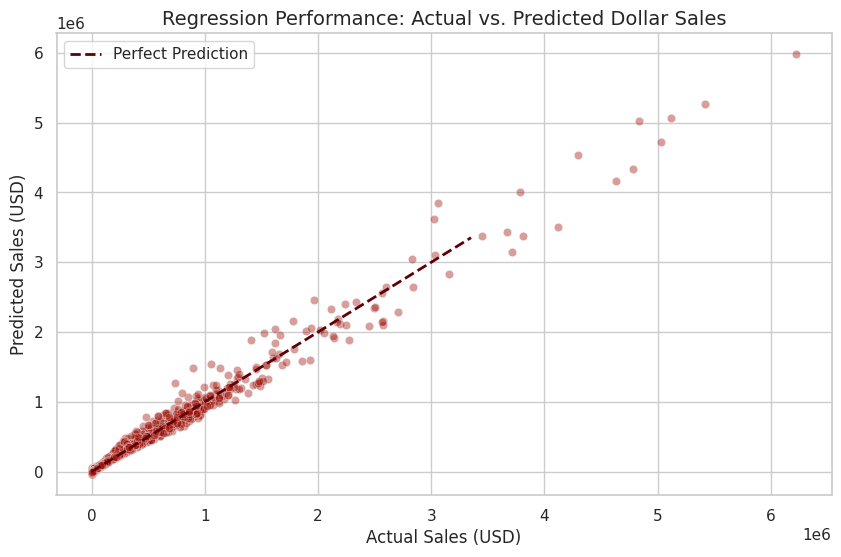

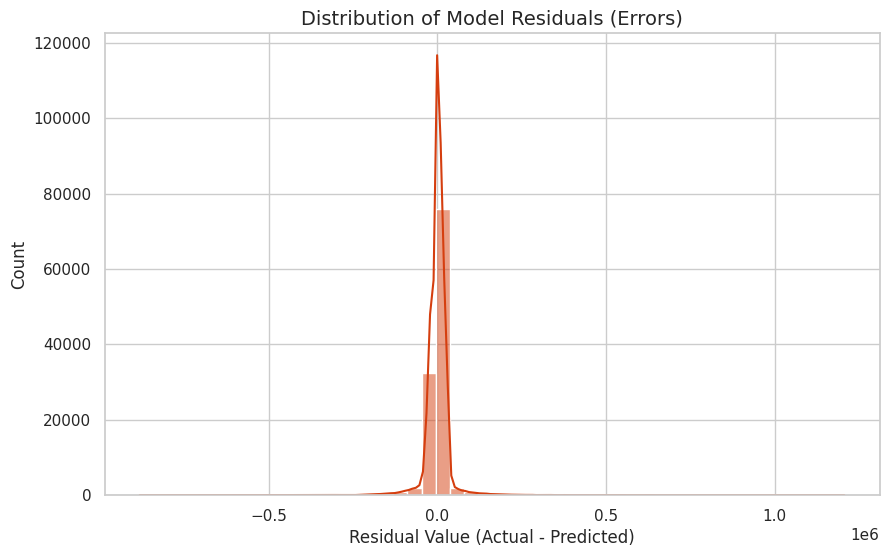

In [8]:
# 1. Actual vs. Predicted Plot
plt.figure(figsize=(10, 6))

# Plotting a subset of the data (5000 points) for visual clarity due to large N
sample_indices = np.random.choice(df.index, 5000, replace=False)
sns.scatterplot(
    x=df.loc[sample_indices, 'dollar_sales_usd'], 
    y=reg_model.predict(X_sm.iloc[sample_indices].astype(float)), 
    alpha=0.4, 
    color='#9b0f06' # Custom Palette: Deep Red
)

# Reference line for a perfect prediction
max_val = df['dollar_sales_usd'].max()
plt.plot([0, max_val/2], [0, max_val/2], '--', color='#5e0006', lw=2, label='Perfect Prediction')

plt.title('Regression Performance: Actual vs. Predicted Dollar Sales', fontsize=14)
plt.xlabel('Actual Sales (USD)', fontsize=12)
plt.ylabel('Predicted Sales (USD)', fontsize=12)
plt.legend()
plt.show()

# 2. Residual Analysis
plt.figure(figsize=(10, 6))
residuals = df['dollar_sales_usd'] - reg_model.predict(X_sm.astype(float))

sns.histplot(residuals, kde=True, color='#d53e0f', bins=50) # Custom Palette: Orange-Red
plt.title('Distribution of Model Residuals (Errors)', fontsize=14)
plt.xlabel('Residual Value (Actual - Predicted)', fontsize=12)
plt.show()

### Interpretation

* **Actual vs. Predicted:** The points cluster tightly along the 45-degree reference line, confirming the high $R^2$ **(0.983)**. This indicates that the combination of unit volume, price, and product type is a near-perfect linear predictor of revenue. However, the slight widening of the cluster at higher values suggests **heteroscedasticity**—the model's error variance increases as the sales volume grows.
* **Residual Distribution:** While the distribution is centered near zero, the long tails and the high Omnibus score from the statistical summary indicate that the errors are not perfectly normal. In a business context, this means while the model is excellent for average predictions, it may under-predict extreme **"blockbuster"** brand-state combinations.



---

# Executive Summary & Actionable Insights
This summary now incorporates the findings from the regression modeling alongside the initial EDA.

### 1. The "Disposable" Revolution vs. "Prefilled" Premium
EDA shows **"Disposables"** now dominate the volume of records and total growth. However, the regression coefficient for `is_prefilled` (**+$14,500**) shows that for a given unit volume, prefilled cartridges generate significantly higher total revenue.
* **Insight:** The market is bifurcating: Disposables drive the growth, while Prefilled Cartridges drive margin efficiency.

### 2. Quantifying Price and Tax Elasticity
The regression model successfully isolated the impact of external levers. Every **1 USD** increase in unit price adds **~5,450 USD** to monthly record revenue, while excise taxes act as a significant drag (**$p < 0.001$**).
* **Insight:** Pricing power remains strong, but heavy state-level taxation is a non-trivial headwind that requires localized pricing strategies.

### 3. Predictive Accuracy and Model Limitations
We achieved a high predictive accuracy (**$R^2 = 0.983$**), but the residual analysis reveals non-normal error distributions.
* **Insight:** Standard linear models are sufficient for general reporting, but for high-stakes financial forecasting, the organization should move toward **Log-Linear** or **Tree-based (XGBoost)** models to better account for the extreme outliers in top-performing brands.

### 4. Strategic Recommendations
* **Target Low-Tax Jurisdictions:** Prioritize marketing spend in states with lower excise tax rates to maximize the "Dollar-per-Unit" yield identified in the regression.
* **Portfolio Balance:** Balance the high-volume growth of Disposables with the higher-revenue-per-unit stability of Prefilled Cartridges to insulate the bottom line from regulatory shifts.